In [1]:
import pandas as pd

ratings = pd.read_csv('../data/ml-100k/u.data', sep='\t',
                       names=['user_id', 'item_id', 'rating', 'timestamp'])
users = pd.read_csv('../data/ml-100k/u.user', sep='|',
                     names=['user_id', 'age', 'gender', 'occupation', 'zip_code'])

user_item_matrix = ratings.pivot_table(index='user_id', columns='item_id', values='rating')

1. Sparce Matrix Handling

In [2]:
user_item_filled = user_item_matrix.fillna(0)

2. Encoding demographic features

In [3]:
users_encoded = pd.get_dummies(users, columns=['gender', 'occupation'], drop_first=True)

users_encoded = users_encoded.drop(columns=['zip_code']).set_index('user_id')

3. Combine ratings + demographic features into one matrix

In [4]:
combined_features = user_item_filled.join(users_encoded)
combined_features.columns = combined_features.columns.astype(str)
print(combined_features.shape)
combined_features.head()

(943, 1704)


,1,2,3,4,5,6,7,8,9,10,...,occupation_marketing,occupation_none,occupation_other,occupation_programmer,occupation_retired,occupation_salesman,occupation_scientist,occupation_student,occupation_technician,occupation_writer
user_id,,,,,,,,,,,,,,,,,,,,,
1,5.0,3.0,4.0,3.0,3.0,5.0,4.0,1.0,5.0,3.0,...,False,False,False,False,False,False,False,False,True,False
2,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,...,False,False,True,False,False,False,False,False,False,False
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,False,True
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,True,False
5,4.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,False,False,True,False,False,False,False,False,False,False


4. Scale Everything

In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_features = scaler.fit_transform(combined_features)
print(scaled_features.shape)

(943, 1704)


5. Perform PCA to reduce dimensionality

In [8]:
from sklearn.decomposition import PCA

pca = PCA(n_components=241)
reduced_features = pca.fit_transform(scaled_features)
print("Variance explained by 241 components: ", round(sum(pca.explained_variance_ratio_), 2))

Variance explained by 241 components:  0.8


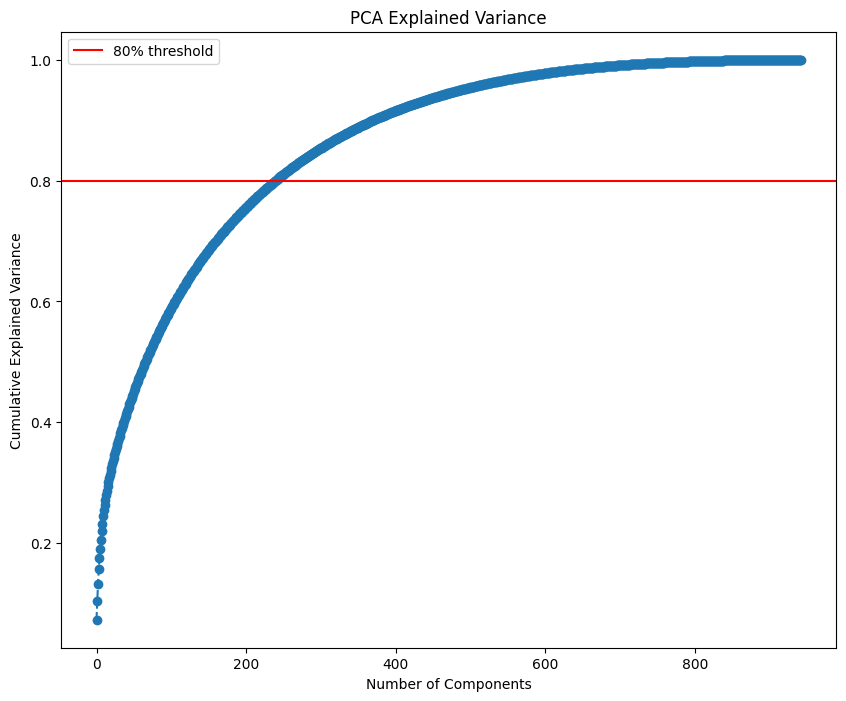

Components needed for 80% variance: 241


In [ ]:

#Deletable code snippet
#Reason: was used to determine the number of components needed to explain 80% of the variance, but we have already set n_components=241 which explains more than 80% of the variance.
import numpy as np
import matplotlib.pyplot as plt


pca_full =  PCA().fit(scaled_features)
cumulative_Variance = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(10, 8))
plt.plot(cumulative_Variance, marker='o', linestyle='--')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')
plt.axhline(y=0.80, color='r', linestyle='-', label = '80% threshold')
plt.legend()
plt.show()

n_components_80 = np.argmax(cumulative_Variance >= 0.80) + 1
print(f"Components needed for 80% variance: {n_components_80}")